<a href="https://colab.research.google.com/github/EduardoKenzoHayashi/CN-Lobosco/blob/main/Atividade1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

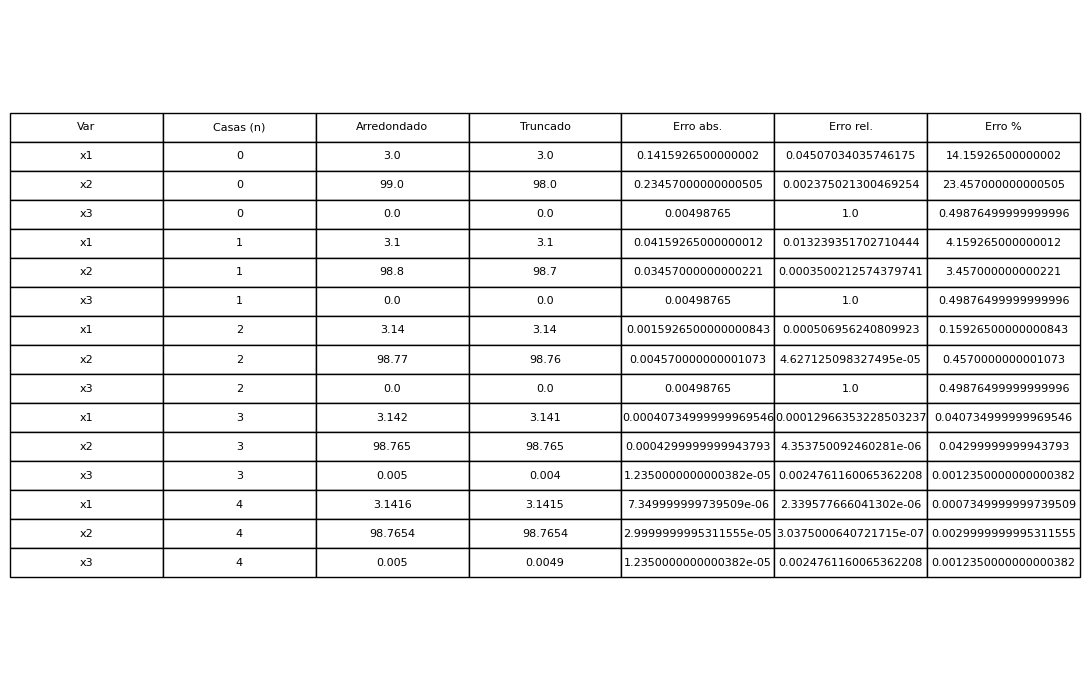

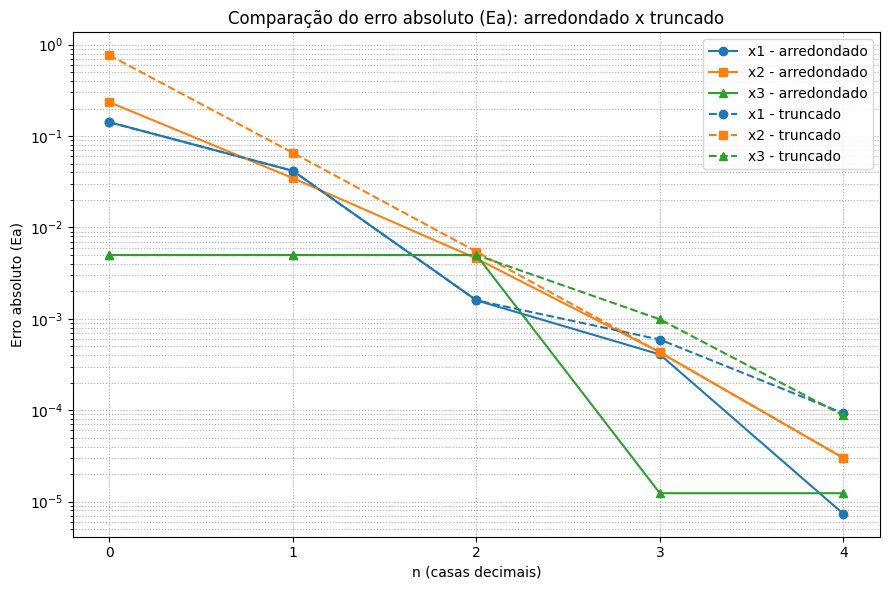

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
def truncar(numero, casas):
    # Calcula o fator que desloca a vírgula decimal.
    fator = 10 ** casas

    # Trunca o número deslocado e devolve a vírgula à posição original.
    return math.trunc(numero * fator) / fator

def err_abs(x,n):
  return abs(x-round(x,n))

def err_rel(err,x):
  return err/abs(x)

def err_per(err):
  return err*100

x1 = 3.14159265
x2 = 98.76543
x3 = 0.00498765
linhas = []
for n in range(0,5):
  linhas.append(["x1", n, round(x1,n), truncar(x1,n), err_abs(x1,n), err_rel(err_abs(x1,n), x1), err_per(err_abs(x1,n))])
  linhas.append(["x2", n, round(x2,n), truncar(x2,n), err_abs(x2,n), err_rel(err_abs(x2,n), x2), err_per(err_abs(x2,n))])
  linhas.append(["x3", n, round(x3,n), truncar(x3,n), err_abs(x3,n), err_rel(err_abs(x3,n), x3), err_per(err_abs(x3,n))])
#fim for
colunas = [
    "Var", "Casas (n)", "Arredondado",
    "Truncado", "Erro abs.", "Erro rel.", "Erro %"
]

fig, ax = plt.subplots(figsize=(11, 7))
ax.axis('off')

tabela = ax.table(cellText=linhas, colLabels=colunas, loc='center', cellLoc='center')
tabela.auto_set_font_size(False)
tabela.set_fontsize(8)
tabela.scale(1, 1.4)
plt.tight_layout()
plt.show()
# --- Gráfico de Ea em função de n (escala log no eixo y) ---

# Função auxiliar para calcular o erro absoluto do valor TRUNCADO.
# Repara que é igual à ideia do err_abs, mas comparando x com truncar(x, n)
# em vez de comparar x com round(x, n).
def err_abs_trunc(x, n):
    return abs(x - truncar(x, n))

# Lista com os valores de n usados na tabela (0, 1, 2, 3, 4).
ns = list(range(0, 5))

# --- Erros absolutos usando ARREDONDAMENTO (round) ---
# Para cada n, calcula o Ea de x1 comparando x1 com round(x1, n).
ea_x1_round = [err_abs(x1, n) for n in ns]
# Mesma lógica para x2.
ea_x2_round = [err_abs(x2, n) for n in ns]
# Mesma lógica para x3.
ea_x3_round = [err_abs(x3, n) for n in ns]

# --- Erros absolutos usando TRUNCAMENTO (truncar) ---
# Para cada n, calcula o Ea de x1 comparando x1 com truncar(x1, n).
ea_x1_trunc = [err_abs_trunc(x1, n) for n in ns]
# Mesma lógica para x2.
ea_x2_trunc = [err_abs_trunc(x2, n) for n in ns]
# Mesma lógica para x3.
ea_x3_trunc = [err_abs_trunc(x3, n) for n in ns]

# Cria uma nova figura (janela do gráfico) com tamanho 9x6 polegadas.
plt.figure(figsize=(9, 6))

# --- Curvas do arredondamento (linha cheia) ---
# Plota Ea de x1 (arredondado) em função de n, com escala log no eixo Y.
#sesmiology é usado quando os dados têm uma diferença muito grande de escala entre os valores, e um gráfico linear normal esconderia essa diferença.
plt.semilogy(ns, ea_x1_round, marker='o', linestyle='-', color='tab:blue', label='x1 - arredondado')
# Plota Ea de x2 (arredondado) em função de n.
plt.semilogy(ns, ea_x2_round, marker='s', linestyle='-', color='tab:orange', label='x2 - arredondado')
# Plota Ea de x3 (arredondado) em função de n.
plt.semilogy(ns, ea_x3_round, marker='^', linestyle='-', color='tab:green', label='x3 - arredondado')

# --- Curvas do truncamento (linha tracejada, mesma cor da variável correspondente) ---
# Plota Ea de x1 (truncado) em função de n. Usa a mesma cor de x1 arredondado,
# mas com linha tracejada ('--'), para ficar fácil comparar visualmente o par.
plt.semilogy(ns, ea_x1_trunc, marker='o', linestyle='--', color='tab:blue', label='x1 - truncado')
# Plota Ea de x2 (truncado) em função de n.
plt.semilogy(ns, ea_x2_trunc, marker='s', linestyle='--', color='tab:orange', label='x2 - truncado')
# Plota Ea de x3 (truncado) em função de n.
plt.semilogy(ns, ea_x3_trunc, marker='^', linestyle='--', color='tab:green', label='x3 - truncado')

# Define o rótulo do eixo X.
plt.xlabel("n (casas decimais)")

# Define o rótulo do eixo Y.
plt.ylabel("Erro absoluto (Ea)")

# Define o título do gráfico, deixando claro que é uma comparação.
plt.title("Comparação do erro absoluto (Ea): arredondado x truncado")

# Garante que o eixo X mostre exatamente os valores inteiros de n (0,1,2,3,4).
plt.xticks(ns)

# Mostra a legenda com todas as 6 curvas (3 arredondadas + 3 truncadas).
plt.legend()

# Adiciona grade pontilhada nas linhas principais e secundárias
# (facilita muito a leitura em escala logarítmica).
plt.grid(True, which="both", ls=":")

# Ajusta os espaçamentos automaticamente para nada ficar cortado.
plt.tight_layout()

# Renderiza o gráfico na tela.
plt.show()

Olhando os gráficos, arrendodar gera um erro menor ou igual ao erro absoluto gerado por valores truncados

In [9]:
orig = [121.7 , 120.4 , 122.1 , 119.8 , 121.2 , 120.9 , 122.4 , 121.0 , 120.2 , 121.5]
arre = []
trunc = []
def media(lista, qtd):
  soma = 0
  for i in lista:
    soma += i
  return soma / qtd

def minimo(lista):
  min = lista[0]
  for i in lista:
    if(i < min):
      min = i
  return min

def maximo(lista):
  max = lista[0]
  for i in lista:
    if(i > max):
      max = i
  return max

def amp(lista):
  mini = minimo(lista)
  maxi = maximo(lista)
  return abs(maxi - mini)

def desviop(lista, n):
  med = media(lista, n)
  desvio = 0
  for i  in lista:
    desvio += ((med - i) ** 2)
  desvio = (desvio / (n - 1)) ** (1/2)
  return desvio

for o in orig:
  arr = round(o , 0)
  arre.append(arr)
  trun = truncar(o , 0)
  trunc.append(trun)

medo = media(orig , 10)
mino = minimo(orig)
maxo = maximo(orig)
ampo = amp(orig)
dpo = desviop(orig , 10)

print(f"A média original é {medo}")
print(f"O mínimo original é {mino}")
print(f"O máximo original é {maxo}")
print(f"A amplitude original é {ampo}")
print(f"O desvio padrão original é {dpo}")

medarre = media(arre , 10)
mina = minimo(arre)
maxa = maximo(arre)
ampa = amp(arre)
dpa = desviop(arre , 10)

print(f"A média arredondada é {medarre}")
print(f"O mínimo arredondado é {mina}")
print(f"O máximo arredondado é {maxa}")
print(f"A amplitude arredondada é {ampa}")
print(f"O desvio padrão arredondado é {dpa}")

medtrunc = media(trunc , 10)
mint = minimo(trunc)
maxt = maximo(trunc)
ampt = amp(trunc)
dtp = desviop(trunc , 10)

print(f"A média truncada é {medtrunc}")
print(f"O minimo truncado é {mint}")
print(f"O máximo truncado é {maxt}")
print(f"A amplitude truncada é {ampt}")
print(f"O desvio padrão truncado é {dtp}")





A média original é 121.12
O mínimo original é 119.8
O máximo original é 122.4
A amplitude original é 2.6000000000000085
O desvio padrão original é 0.8337332373793856
A média arredondada é 121.1
O mínimo arredondado é 120.0
O máximo arredondado é 122.0
A amplitude arredondada é 2.0
O desvio padrão arredondado é 0.8755950357709131
A média truncada é 120.7
O minimo truncado é 119.0
O máximo truncado é 122.0
A amplitude truncada é 3.0
O desvio padrão truncado é 0.9486832980505138


In [10]:
def cebs(referencia, aproximado):
  return abs(referencia - aproximado)
eaarr = cebs (medo,medarre)
erarr = err_rel (eaarr, medo)
eparr = err_per (erarr)
print(f"O erro absoluto da média arredondada é {eaarr}")
print(f"O erro relativo da média arredondada é {erarr}")
print(f"O erro percentual da média arredondada é {eparr}")

eatrunc = cebs (medo, medtrunc)
ertrunc = err_rel (eatrunc, medo)
eptrunc = err_per (ertrunc)
print(f"O erro absoluto da média truncada é {eatrunc}")
print(f"O erro relativo da média truncada é {ertrunc}")
print(f"O erro percentual da média truncada é {eptrunc}")

O erro absoluto da média arredondada é 0.020000000000010232
O erro relativo da média arredondada é 0.0001651254953765706
O erro percentual da média arredondada é 0.01651254953765706
O erro absoluto da média truncada é 0.4200000000000017
O erro relativo da média truncada é 0.003467635402906223
O erro percentual da média truncada é 0.3467635402906223


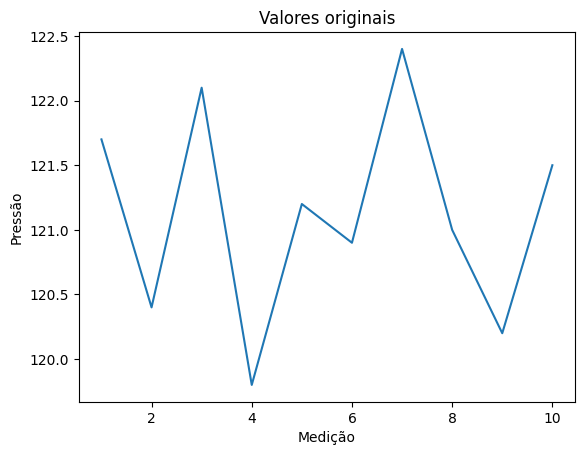

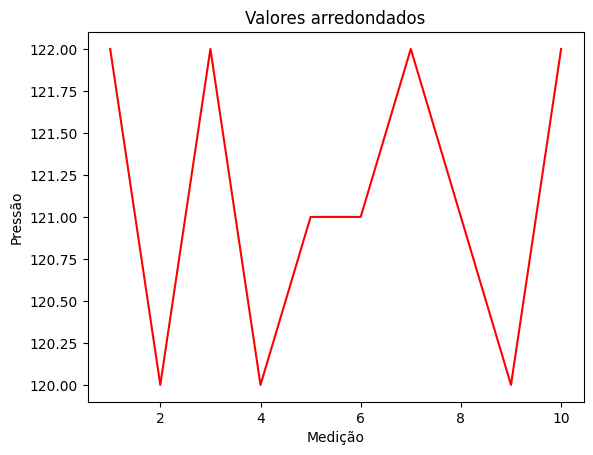

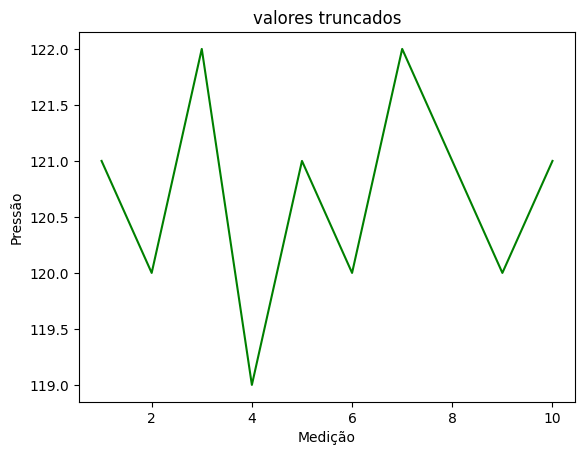

In [16]:
#há 10 valores, logo x varia de 1 at´pe 10
x = np.arange(1, 11, 1)
#gráfico das medições original
plt.plot(x , orig)
plt.xlabel ("Medição")
plt.ylabel ("Pressão")
plt.title("Valores originais")
plt.show()

#gráfico das medições arredondadas
plt.plot(x, arre, color = "red")
plt.xlabel ("Medição")
plt.ylabel ("Pressão")
plt.title("Valores arredondados")
plt.show()

#gráfico dos valores truncados
plt.plot(x, trunc, color = "green")
plt.xlabel("Medição")
plt.ylabel ("Pressão")
plt.title("valores truncados")
plt.show()

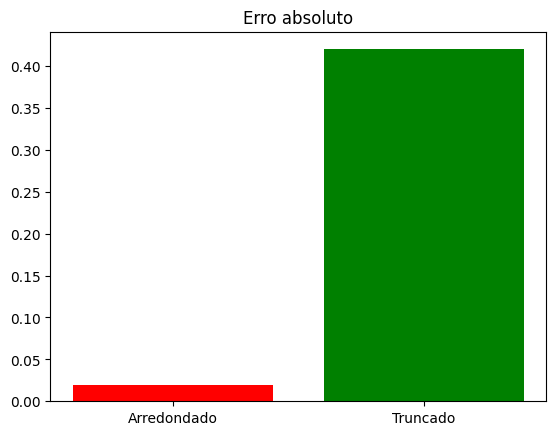

In [19]:

categorias = [ "Arredondado","Truncado" ]
erros_abs = [eaarr, eatrunc]
plt.bar(categorias,erros_abs,color = ["red","green"])
plt.title("Erro absoluto")
plt.show()

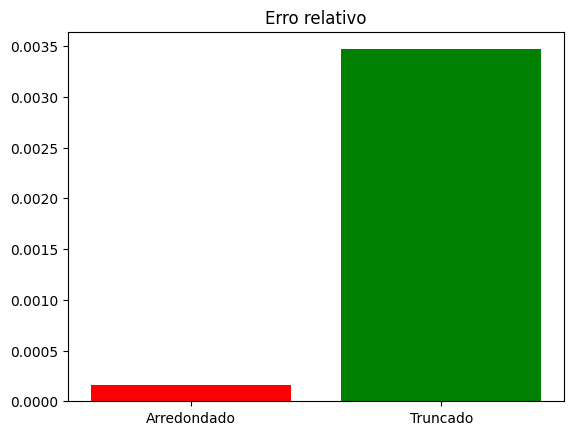

In [20]:
erros_rel = [erarr, ertrunc]
plt.bar(categorias, erros_rel, color = ['red','green'])
plt.title("Erro relativo")
plt.show()

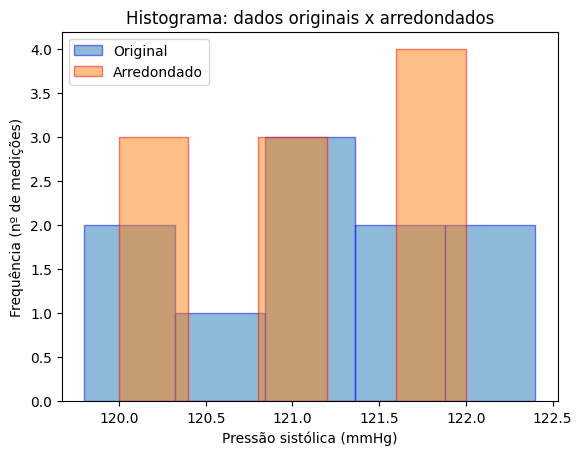

In [14]:
plt.hist(orig, bins = 5, alpha = 0.5, label = "Original", edgecolor = "blue")
plt.hist(arre, bins = 5 , alpha = 0.5, label = "Arredondado", edgecolor = 'red')
plt.xlabel('Pressão sistólica (mmHg)')
plt.ylabel('Frequência (nº de medições)')
plt.title('Histograma: dados originais x arredondados')
plt.legend()
plt.show()

Não, pois há dados nas casas decimais que seriam desprezadas pelo arredondamento ou truncamento que podem influenciar de forma significativa no cálculo da média e no cálculo do desvio padrão. Isso pode ser visto nos resultados obtidos ao compararmos o vbalor das médias e dos desvios padrões das três séries analisadas.

In [21]:
#função que calcula Q
def calQ(rmm, p, mi, L):
  return math.pi*((rmm*(10**-3))**4)*p/(8*mi*L)
ro = 0.8
Lo = 0.2
mio = 3.5e-3
pio = 1200

In [25]:
print(f"O valor de Q vale {calQ(ro,pio,mio,Lo)}")

O valor de Q vale 2.757420751950813e-07


In [28]:
ra = round(ro , 1)
rt = truncar(ro, 1)
Qo = calQ(ro,pio,mio,Lo)
Qra = calQ(ra,pio,mio,Lo)
Qrt = calQ(rt,pio,mio,Lo)

print(f"O valor de Q com r arredondado vale {Qra}")

eara = cebs(Qo,Qra)
erra = err_rel(eara, Qo)
epra = err_per(erra)

print(f"O erro absoluto de Q com r arredondado vale {eara}")
print(f"O erro relativo de Q com r arredondado vale {erra}")
print(f"O erro percentual de Q com r arredondado vale {epra}")

print(f"O valor de Q com r truncado vale {Qrt}")

eart = cebs(Qo,Qrt)
errt = err_rel(eart, Qo)
eprt = err_per(errt)

print(f"O erro absoluto de Q com r truncado vale {eart}")
print(f"O erro relativo de Q com r truncado vale {errt}")
print(f"O erro percentual de Q com r truncado vale {eprt}")



O valor de Q com r arredondado vale 2.757420751950813e-07
O erro absoluto de Q com r arredondado vale 0.0
O erro relativo de Q com r arredondado vale 0.0
O erro percentual de Q com r arredondado vale 0.0
O valor de Q com r truncado vale 2.757420751950813e-07
O erro absoluto de Q com r truncado vale 0.0
O erro relativo de Q com r truncado vale 0.0
O erro percentual de Q com r truncado vale 0.0


In [29]:
miar = round(mio, 3)
mit = truncar(mio, 3)
Qmiar = calQ(ro,pio,miar,Lo)
Qmit = calQ(ro,pio,mit,Lo)

print(f"O valor de Q com mi arredondado vale {Qmiar}")
eamiar = cebs(Qo,Qmiar)
ermiar = err_rel(eamiar, Qo)
epmiar = err_per(ermiar)
print(f"O erro absoluto de Q com mi arredondado vale {eamiar}")
print(f"O erro relativo de Q com mi arredondado vale {ermiar}")
print(f"O erro percentual de Q com mi arredondado vale {epmiar}")

print(f"O valor de Q com mi truncado vale {Qmit}")
eamit = cebs(Qo,Qmit)
ermit = err_rel(eamit, Qo)
epmit = err_per(ermit)
print(f'O erro absoluto de Q com mi truncado vale {eamit}')
print(f"O erro relativo de Q com mi truncado vale {ermit}")
print(f"O erro percentual de Q com mi truncado vale {epmit}")


O valor de Q com mi arredondado vale 2.4127431579569616e-07
O erro absoluto de Q com mi arredondado vale 3.446775939938513e-08
O erro relativo de Q com mi arredondado vale 0.12499999999999988
O erro percentual de Q com mi arredondado vale 12.499999999999988
O valor de Q com mi truncado vale 3.2169908772759484e-07
O erro absoluto de Q com mi truncado vale 4.5957012532513556e-08
O erro relativo de Q com mi truncado vale 0.16666666666666669
O erro percentual de Q com mi truncado vale 16.666666666666668


In [30]:
pat = 12
Qpat = calQ(ro,pat,mio,Lo)
print(f"O valor de Q com delta p arredondado/truncado vale {Qpat}")
eapat = cebs(Qo,Qpat)
erpat = err_rel(eapat, Qo)
eppat = err_per(erpat)
print(f"O erro absoluto de Q com delta p arredondado/truncado vale {eapat}")
print(f"O erro relativo de Q com delta p arredondado/truncado vale {erpat}")
print(f"O erro percentual de Q com delta p arredondado/truncado vale {eppat}")


O valor de Q com delta p arredondado/trucado vale 2.7574207519508133e-09
O erro absoluto de Q com delta p arredondado/trucado vale 2.7298465444313047e-07
O erro relativo de Q com delta p arredondado/trucado vale 0.99
O erro percentual de Q com delta p arredondado/trucado vale 99.0


In [31]:
Qtudoar = calQ(ra,pat,miar,Lo)
print(f"O valor de Q com tudo arredondado vale {Qtudoar}")
eatudo = cebs(Qo,Qtudoar)
ertudo = err_rel(eatudo, Qo)
eptudo = err_per(ertudo)
print(f"O erro absoluto de Q com tudo arredondado vale {eatudo}")
print(f"O erro relativo de Q com tudo arredondado vale {ertudo}")
print(f"O erro percentual de Q com tudo arredondado vale {eptudo}")

Qtudot = calQ(rt,pat,mit,Lo)
print(f"O valor de Q com tudo truncado vale {Qtudot}")
eatudo = cebs(Qo,Qtudot)
ertudo = err_rel(eatudo, Qo)
eptudo = err_per(ertudo)
print(f"O erro absoluto de Q com tudo truncado vale {eatudo}")
print(f"O erro relativo de Q com tudo truncado vale {ertudo}")
print(f"O erro percentual de Q com tudo truncado vale {eptudo}")

O valor de Q com tudo arredondado vale 2.4127431579569616e-09
O erro absoluto de Q com tudo arredondado vale 2.7332933203712433e-07
O erro relativo de Q com tudo arredondado vale 0.99125
O erro percentual de Q com tudo arredondado vale 99.125
O valor de Q com tudo truncado vale 3.216990877275949e-09
O erro absoluto de Q com tudo truncado vale 2.7252508431780536e-07
O erro relativo de Q com tudo truncado vale 0.9883333333333334
O erro percentual de Q com tudo truncado vale 98.83333333333334


In [32]:
rmm = np.arange(0.7,0.9+1e-9,0.01)
Qvaloresnorm = []
Qvaloresa = []
Qvalorest = []
for r in rmm:
  Qvaloresnorm.append(calQ(r,pio,mio,Lo))
  Qvaloresa.append(calQ(round(r,1),pio,mio,Lo))
  Qvalorest.append(calQ(truncar(r,1),pio,mio,Lo))


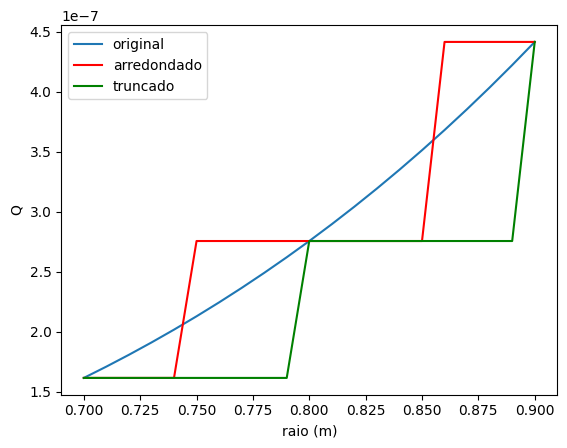

In [35]:
plt.plot(rmm, Qvaloresnorm, label = "original")
plt.plot(rmm, Qvaloresa, color = "red", label = "arredondado")
plt.plot(rmm, Qvalorest, color = "green", label = "truncado")
plt.xlabel("raio (m)")
plt.ylabel("Q")
plt.legend()
plt.show()

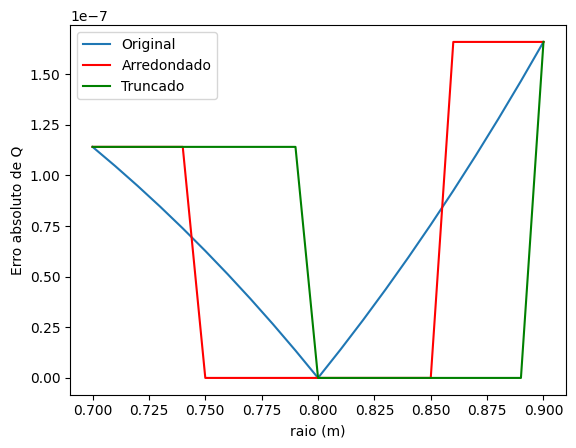

In [36]:
EaQn = []
for i in Qvaloresnorm:
  EaQn.append(cebs(Qo,i))

EaQa = []
for i in Qvaloresa:
  EaQa.append(cebs(Qo,i))

EaQt = []
for i in Qvalorest:
  EaQt.append(cebs(Qo,i))
plt.plot(rmm, EaQn, label = "Original")
plt.plot(rmm, EaQa, color = "red", label = "Arredondado")
plt.plot(rmm, EaQt, color = "green", label = "Truncado")
plt.xlabel("raio (m)")
plt.ylabel("Erro absoluto de Q")
plt.legend()
plt.show()

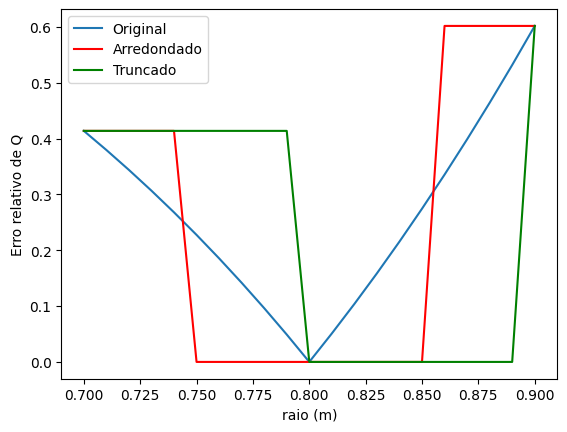

In [37]:
ErQn = []
ErQa = []
ErQt = []
for i in Qvaloresnorm:
  ErQn.append(err_rel(cebs(Qo,i),Qo))

for i in Qvaloresa:
  ErQa.append(err_rel(cebs(Qo,i),Qo))

for i in Qvalorest:
  ErQt.append(err_rel(cebs(Qo,i),Qo))
plt.plot(rmm, ErQn, label = "Original")
plt.plot(rmm, ErQa, color = "red", label = "Arredondado")
plt.plot(rmm, ErQt, color = "green", label = "Truncado")
plt.xlabel("raio (m)")
plt.ylabel("Erro relativo de Q")
plt.legend()
plt.show()

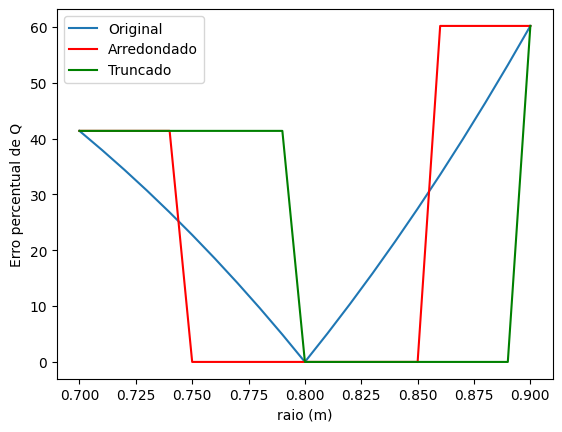

In [38]:
EpQn = []
EpQa = []
EpQt = []
for i in ErQn:
  EpQn.append(err_per(i))

for i in ErQa:
  EpQa.append(err_per(i))

for i in ErQt:
  EpQt.append(err_per(i))

plt.plot(rmm, EpQn, label = "Original")
plt.plot(rmm, EpQa, color = "red", label = "Arredondado")
plt.plot(rmm, EpQt, color = "green", label = "Truncado")
plt.xlabel("raio (m)")
plt.ylabel("Erro percentual de Q")
plt.legend()
plt.show()